# Experimento de Difração de fio de cabelo

In [2]:
# Cálculo do diâmetro de um fio de cabelo por difração

# Entrada de dados
lambda_nm = float(input("Comprimento de onda do laser (nm): "))
L = float(input("Distância até o anteparo (m): "))
delta_y = float(input("Distância entre franjas (mm): "))

# Conversões
lambda_m = lambda_nm * 1e-9   # nm → m
delta_y_m = delta_y * 1e-3    # mm para m

# Cálculo
diametro = (lambda_m * L) / delta_y_m

# Resultado
print(f"Diâmetro do fio de cabelo: {diametro:.2e} m")
print(f"Ou aproximadamente: {diametro*1e6:.2f} micrômetros (µm)")


Comprimento de onda do laser (nm):  520
Distância até o anteparo (m):  7.10
Distância entre franjas (mm):  31


Diâmetro do fio de cabelo: 1.19e-04 m
Ou aproximadamente: 119.10 micrômetros (µm)


In [2]:
import numpy as np
from scipy import stats

In [3]:
# Distância L (m)
L = np.array([2.8, 3.5, 4.2, 7.1])

# Espaçamento das franjas (m)
delta_y = np.array([0.01290, 0.02077, 0.02630, 0.03102])

In [4]:
slope, intercept, r, p, std_err = stats.linregress(L, delta_y)

print("Inclinação (m):", slope)
print("Intercepto:", intercept)
print("Erro da inclinação:", std_err)

Inclinação (m): 0.0036599065420560746
Intercepto: 0.006643911214953266
Erro da inclinação: 0.001343253737426196


In [5]:
# Comprimento de onda do laser (em metros)
lambda_laser = 520e-9  # ajuste conforme seu laser

# Espessura do cabelo
d = lambda_laser / slope

print("Espessura do cabelo (m):", d)


Espessura do cabelo (m): 0.00014208013074232018


In [6]:
# Erros experimentais (ajuste conforme seu experimento)
erro_L = 0.001  # erro médio em L
erro_m = std_err

# Propagação de erro
erro_d = d * np.sqrt((erro_L / np.mean(L))**2 + (erro_m / slope)**2)

print("d =", d, "+/-", erro_d)

d = 0.00014208013074232018 +/- 5.214605920452845e-05


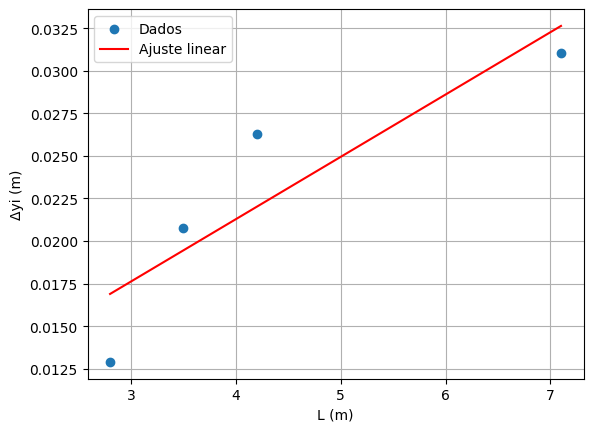

In [7]:
import matplotlib.pyplot as plt

plt.scatter(L, delta_y, label="Dados")
plt.plot(L, slope*L + intercept, color="red", label="Ajuste linear")
plt.xlabel("L (m)")
plt.ylabel("Δyi (m)")
plt.legend()
plt.grid()
plt.show()

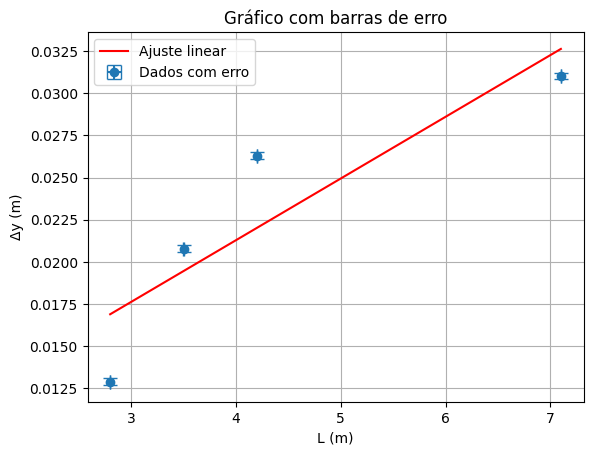

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Dados (substitua pelos seus)
L = np.array([2.8, 3.5, 4.2, 7.1])
delta_y = np.array([0.01290, 0.02077, 0.02630, 0.03102])

# Erros (defina conforme seu experimento)
erro_L = 0.001 * np.ones_like(L)        # erro em L
erro_dy = 0.0002 * np.ones_like(delta_y)  # erro em Δy

# Regressão linear
from scipy import stats
slope, intercept, r, p, std_err = stats.linregress(L, delta_y)

# Gráfico com barras de erro
plt.errorbar(
    L, delta_y,
    xerr=erro_L,
    yerr=erro_dy,
    fmt='o',
    capsize=5,
    label="Dados com erro"
)

# Linha do ajuste
plt.plot(L, slope*L + intercept, color="red", label="Ajuste linear")

# Detalhes
plt.xlabel("L (m)")
plt.ylabel("Δy (m)")
plt.title("Gráfico com barras de erro")
plt.legend()
plt.grid()

plt.show()

In [9]:
# Valor medido no microscópio (exemplo)
d_micro = 109e-6

# Diferença percentual
erro_percentual = abs(d - d_micro) / d_micro * 100

print("Erro percentual:", erro_percentual, "%")

Erro percentual: 30.348743800293732 %
